# 🎯 Notebook 05: Análisis Espacial de Resiliencia Multi-Modelo

## 📋 Compatibilidad con Workflow Actualizado

✅ **Compatible con:**
- **04a_latent_visualization.ipynb**: Comparación de 3 modelos de autoencoder
- **04_clustering.ipynb**: Clustering multi-modelo + índices de resiliencia
- **Resultados exportados**: `resilience_multimodel_test.pkl`

## ? Enfoque Multi-Modelo

Este notebook carga y visualiza los **9 índices de resiliencia** (3 modelos × 3 escenarios) calculados en el notebook 04, permitiendo:

1. **Comparación inter-modelo**: ¿Model_A, Model_B y Model_C predicen patrones similares?
2. **Análisis espacial**: Mapas de resiliencia por modelo y escenario
3. **Identificación de zonas críticas**: Áreas resilientes/vulnerables consistentes entre modelos
4. **Validación de robustez**: Zonas donde los 3 modelos concuerdan

## 📊 Datos de Entrada

- **Clustering multi-modelo**: `clustering_multimodel_test.pkl`
- **Índices de resiliencia**: `resilience_multimodel_test.pkl`
- **Metadata**: `resilience_multimodel_metadata_test.json`
- **Correlaciones**: `resilience_multimodel_correlations_test.csv`

## 🎯 Objetivos del Análisis

1. **Mapas espaciales comparativos**: Visualizar resiliencia por modelo y escenario
2. **Consenso multi-modelo**: Identificar zonas donde los 3 modelos concuerdan
3. **Análisis de incertidumbre**: Variabilidad entre modelos como proxy de incertidumbre
4. **Zonas críticas persistentes**: Áreas resilientes/vulnerables en todos los modelos
5. **Comparación de componentes**: Cohesión, favorabilidad, estabilidad, exposición

## 📝 Pipeline:

1. Imports y configuración
2. Cargar resultados multi-modelo del notebook 04
3. Cargar información espacial (coordenadas, máscara)
4. Análisis de consenso entre modelos
5. Mapas espaciales comparativos
6. Identificación de zonas críticas
7. Análisis de componentes del índice
8. Exportar resultados consolidados

---

**Nota**: Este notebook se enfoca en **análisis espacial y comparación de modelos**, no en cálculo de índices (eso se hace en el notebook 04).

---
## 1️⃣ Imports y Configuración

In [41]:
# ===== IMPORTS PRINCIPALES =====
from pathlib import Path
import json
import pickle
import warnings
warnings.filterwarnings('ignore')
import os

# Análisis numérico
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import seaborn as sns

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances

# Distancias
from scipy.spatial.distance import euclidean, cdist
from scipy.stats import pearsonr, zscore

# Configuración de matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11

print("✅ Imports completados")

✅ Imports completados


In [2]:
# ===== CONFIGURACIÓN DE RUTAS =====
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
RESULTS_DIR = BASE_DIR / 'data' / 'autoencoder_results'
TENSORS_DIR = BASE_DIR / 'data' / 'autoencoder_tensors'
PLOTS_DIR = BASE_DIR / 'plots' / 'resilience_analysis'
REPORTS_DIR = BASE_DIR / 'reports'

# Crear directorios si no existen
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

MODE = 'test'
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']

print(f"{'='*80}")
print(f"📁 CONFIGURACIÓN ANÁLISIS MULTI-MODELO")
print(f"{'='*80}")
print(f"\nDirectorios:")
print(f"   Resultados: {RESULTS_DIR}")
print(f"   Plots: {PLOTS_DIR}")
print(f"   Reportes: {REPORTS_DIR}")
print(f"\n🌍 Escenarios: {', '.join([s.upper() for s in SCENARIOS])}")
print(f"🔧 Modo: {MODE}")
print(f"\n{'='*80}")

📁 CONFIGURACIÓN ANÁLISIS MULTI-MODELO

Directorios:
   Resultados: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_results
   Plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_analysis
   Reportes: /home/aninotna/magister/tesis/justh2_pipeline/reports

🌍 Escenarios: SSP245, SSP370, SSP585
🔧 Modo: test



---
## 2️⃣ Cargar Resultados Multi-Modelo del Notebook 04

In [5]:
# ===== CARGAR RESULTADOS MULTI-MODELO =====
print(f"\n{'='*80}")
print(f"CARGANDO RESULTADOS MULTI-MODELO DEL NOTEBOOK 04")
print(f"{'='*80}")

# Cargar metadata
metadata_file = RESULTS_DIR / f'resilience_multimodel_metadata_{MODE}.json'
if not metadata_file.exists():
    raise FileNotFoundError(
        f"❌ No se encontró {metadata_file.name}\n"
        f"   Ejecuta el notebook 04_clustering.ipynb primero para generar los resultados."
    )

print(f"\n📋 Cargando metadata...")
with open(metadata_file, 'r') as f:
    metadata = json.load(f)

MODELS = metadata['models']
n_features = metadata['n_features']
feature_names = metadata['feature_names']
spatial_info = metadata['spatial_info']

print(f"   ✅ Modelos: {MODELS}")
print(f"   ✅ Features: {n_features}")
print(f"   ✅ Escenarios: {metadata['scenarios']}")

# Cargar índices de resiliencia
resilience_file = RESULTS_DIR / f'resilience_multimodel_{MODE}.pkl'
if not resilience_file.exists():
    raise FileNotFoundError(
        f"❌ No se encontró {resilience_file.name}\n"
        f"   Ejecuta el notebook 04_clustering.ipynb primero."
    )

print(f"\n🎯 Cargando índices de resiliencia...")
with open(resilience_file, 'rb') as f:
    resilience_results = pickle.load(f)

print(f"   ✅ Estructura cargada:")
for model in resilience_results.keys():
    print(f"\n   {model}:")
    for scenario in resilience_results[model].keys():
        n_samples = len(resilience_results[model][scenario]['resilience_index'])
        print(f"      {scenario.upper()}: {n_samples} píxeles")

# Cargar clustering
clustering_file = RESULTS_DIR / f'clustering_multimodel_{MODE}.pkl'
if clustering_file.exists():
    print(f"\n🔬 Cargando clustering...")
    with open(clustering_file, 'rb') as f:
        clustering_results = pickle.load(f)
    print(f"   ✅ Clustering cargado para {len(clustering_results)} modelos")
else:
    print(f"\n⚠️  Clustering no encontrado (opcional)")
    clustering_results = None

# Cargar correlaciones inter-modelo
correlations_file = REPORTS_DIR / f'resilience_multimodel_correlations_{MODE}.csv'
if correlations_file.exists():
    print(f"\n📊 Cargando correlaciones inter-modelo...")
    df_correlations = pd.read_csv(correlations_file)
    print(f"   ✅ Correlaciones cargadas: {len(df_correlations)} pares")
else:
    print(f"\n⚠️  Correlaciones no encontradas (opcional)")
    df_correlations = None

print(f"\n{'='*80}")


CARGANDO RESULTADOS MULTI-MODELO DEL NOTEBOOK 04

📋 Cargando metadata...
   ✅ Modelos: ['Model_A', 'Model_B', 'Model_C']
   ✅ Features: 293
   ✅ Escenarios: ['ssp245', 'ssp370', 'ssp585']

🎯 Cargando índices de resiliencia...
   ✅ Estructura cargada:

   Model_A:
      SSP245: 661 píxeles
      SSP370: 661 píxeles
      SSP585: 661 píxeles

   Model_B:
      SSP245: 661 píxeles
      SSP370: 661 píxeles
      SSP585: 661 píxeles

   Model_C:
      SSP245: 661 píxeles
      SSP370: 661 píxeles
      SSP585: 661 píxeles

🔬 Cargando clustering...
   ✅ Clustering cargado para 3 modelos

📊 Cargando correlaciones inter-modelo...
   ✅ Correlaciones cargadas: 9 pares



In [7]:
# ===== CARGAR INFORMACIÓN ESPACIAL =====
print(f"\n{'='*80}")
print(f"📍 CARGANDO INFORMACIÓN ESPACIAL")
print(f"{'='*80}")

# Cargar directamente desde metadata de tensores (la fuente confiable)
metadata_tensors_file = TENSORS_DIR / f'metadata_{MODE}.pkl'

if not metadata_tensors_file.exists():
    raise FileNotFoundError(
        f"❌ No se encontró {metadata_tensors_file.name}\n"
        f"   Necesario para información espacial."
    )

print(f"\n📂 Cargando coordenadas desde: {metadata_tensors_file.name}")
with open(metadata_tensors_file, 'rb') as f:
    metadata_tensors = pickle.load(f)

MASK = metadata_tensors['mask']
spatial_info_tensors = metadata_tensors['spatial_info']
lat_coords = spatial_info_tensors['lat']
lon_coords = spatial_info_tensors['lon']

# Extraer grid_shape y extent
GRID_SHAPE = MASK.shape
n_valid_pixels = MASK.sum()
EXTENT = [lon_coords.min(), lon_coords.max(), lat_coords.min(), lat_coords.max()]

print(f"   ✅ Máscara: {MASK.shape}")
print(f"   ✅ Píxeles válidos en máscara: {n_valid_pixels}")
print(f"   ✅ Rango lat: [{lat_coords.min():.2f}, {lat_coords.max():.2f}]")
print(f"   ✅ Rango lon: [{lon_coords.min():.2f}, {lon_coords.max():.2f}]")
print(f"   ✅ Grid shape: {GRID_SHAPE}")
print(f"   ✅ Extent: {EXTENT}")

# Crear meshgrid para mapas
lon_grid, lat_grid = np.meshgrid(lon_coords, lat_coords)

print(f"\n{'='*80}")


📍 CARGANDO INFORMACIÓN ESPACIAL

📂 Cargando coordenadas desde: metadata_test.pkl
   ✅ Máscara: (24, 42)
   ✅ Píxeles válidos en máscara: 661
   ✅ Rango lat: [-33.33, -32.17]
   ✅ Rango lon: [-71.97, -69.93]
   ✅ Grid shape: (24, 42)
   ✅ Extent: [np.float64(-71.975), np.float64(-69.92500000000001), np.float64(-33.325), np.float64(-32.175)]



---
## 3️⃣ Análisis de Consenso Multi-Modelo

Calcular estadísticos de resiliencia consensuados entre los 3 modelos para cada píxel y escenario.

In [8]:
# ===== CALCULAR CONSENSO MULTI-MODELO =====
print(f"\n{'='*80}")
print(f"🤝 ANÁLISIS DE CONSENSO MULTI-MODELO")
print(f"{'='*80}")

# Crear arrays para almacenar resiliencia por modelo y escenario
resilience_arrays = {
    scenario: {
        model: resilience_results[model][scenario]['resilience_index']
        for model in MODELS
    }
    for scenario in SCENARIOS
}

# Calcular estadísticos consensuados por escenario
consensus_results = {}

for scenario in SCENARIOS:
    print(f"\n🌍 {scenario.upper()}:")
    
    # Stack de todos los modelos para este escenario
    resilience_stack = np.stack([
        resilience_arrays[scenario][model] 
        for model in MODELS
    ], axis=0)  # Shape: (n_models, n_pixels)
    
    # Estadísticos
    resilience_mean = np.mean(resilience_stack, axis=0)
    resilience_median = np.median(resilience_stack, axis=0)
    resilience_std = np.std(resilience_stack, axis=0)
    resilience_min = np.min(resilience_stack, axis=0)
    resilience_max = np.max(resilience_stack, axis=0)
    
    # Coeficiente de variación (std/mean) como medida de incertidumbre
    resilience_cv = resilience_std / (resilience_mean + 1e-8)
    
    consensus_results[scenario] = {
        'mean': resilience_mean,
        'median': resilience_median,
        'std': resilience_std,
        'min': resilience_min,
        'max': resilience_max,
        'cv': resilience_cv,
        'stack': resilience_stack
    }
    
    print(f"   Media del consenso: {resilience_mean.mean():.3f} ± {resilience_mean.std():.3f}")
    print(f"   Incertidumbre promedio (std): {resilience_std.mean():.3f}")
    print(f"   CV promedio: {resilience_cv.mean():.3f}")

# Identificar píxeles de alto consenso (baja variabilidad entre modelos)
print(f"\n{'='*60}")
print(f"🎯 ZONAS DE ALTO/BAJO CONSENSO")
print(f"{'='*60}")

for scenario in SCENARIOS:
    cv = consensus_results[scenario]['cv']
    high_consensus_mask = cv < 0.1  # CV < 10%
    low_consensus_mask = cv > 0.3   # CV > 30%
    
    print(f"\n{scenario.upper()}:")
    print(f"   Alto consenso (CV<10%): {high_consensus_mask.sum()} píxeles ({100*high_consensus_mask.sum()/len(cv):.1f}%)")
    print(f"   Bajo consenso (CV>30%): {low_consensus_mask.sum()} píxeles ({100*low_consensus_mask.sum()/len(cv):.1f}%)")

print(f"\n{'='*80}")


🤝 ANÁLISIS DE CONSENSO MULTI-MODELO

🌍 SSP245:
   Media del consenso: 0.477 ± 0.060
   Incertidumbre promedio (std): 0.019
   CV promedio: 0.040

🌍 SSP370:
   Media del consenso: 0.534 ± 0.071
   Incertidumbre promedio (std): 0.022
   CV promedio: 0.042

🌍 SSP585:
   Media del consenso: 0.448 ± 0.065
   Incertidumbre promedio (std): 0.020
   CV promedio: 0.046

🎯 ZONAS DE ALTO/BAJO CONSENSO

SSP245:
   Alto consenso (CV<10%): 647 píxeles (97.9%)
   Bajo consenso (CV>30%): 0 píxeles (0.0%)

SSP370:
   Alto consenso (CV<10%): 641 píxeles (97.0%)
   Bajo consenso (CV>30%): 0 píxeles (0.0%)

SSP585:
   Alto consenso (CV<10%): 646 píxeles (97.7%)
   Bajo consenso (CV>30%): 0 píxeles (0.0%)



---
## 4️⃣ Mapas Espaciales Comparativos Multi-Modelo

Visualizar los índices de resiliencia por modelo y escenario, además del consenso entre modelos.

In [10]:
# ===== FUNCIÓN PARA CREAR MAPAS ESPACIALES =====
def create_spatial_map(data_1d, mask, grid_shape):
    """
    Convierte datos 1D (píxeles válidos) a mapa 2D con máscara.
    
    Parameters:
    -----------
    data_1d : array
        Datos 1D para píxeles válidos
    mask : array
        Máscara booleana 2D
    grid_shape : tuple
        Forma del grid (nrows, ncols)
    
    Returns:
    --------
    map_2d : array
        Mapa 2D con NaN donde no hay datos
    """
    # Crear mapa 2D vacío (NaN donde no hay datos)
    map_2d = np.full(grid_shape, np.nan)
    
    # Llenar con datos donde mask=True
    map_2d[MASK] = data_1d
    
    return map_2d

print("✅ Función create_spatial_map definida")

✅ Función create_spatial_map definida



🗺️  GENERANDO MAPAS COMPARATIVOS MULTI-MODELO

Rango global de resiliencia: [0.224, 0.698]

   ✓ Model_A - SSP245: μ=0.488, σ=0.062
   ✓ Model_A - SSP370: μ=0.544, σ=0.081
   ✓ Model_A - SSP585: μ=0.445, σ=0.066
   ✓ Model_B - SSP245: μ=0.471, σ=0.065
   ✓ Model_B - SSP370: μ=0.541, σ=0.073
   ✓ Model_B - SSP585: μ=0.459, σ=0.071
   ✓ Model_C - SSP245: μ=0.471, σ=0.064
   ✓ Model_C - SSP370: μ=0.516, σ=0.070
   ✓ Model_C - SSP585: μ=0.439, σ=0.068

✅ Mapa guardado: resilience_multimodel_comparison_test.png


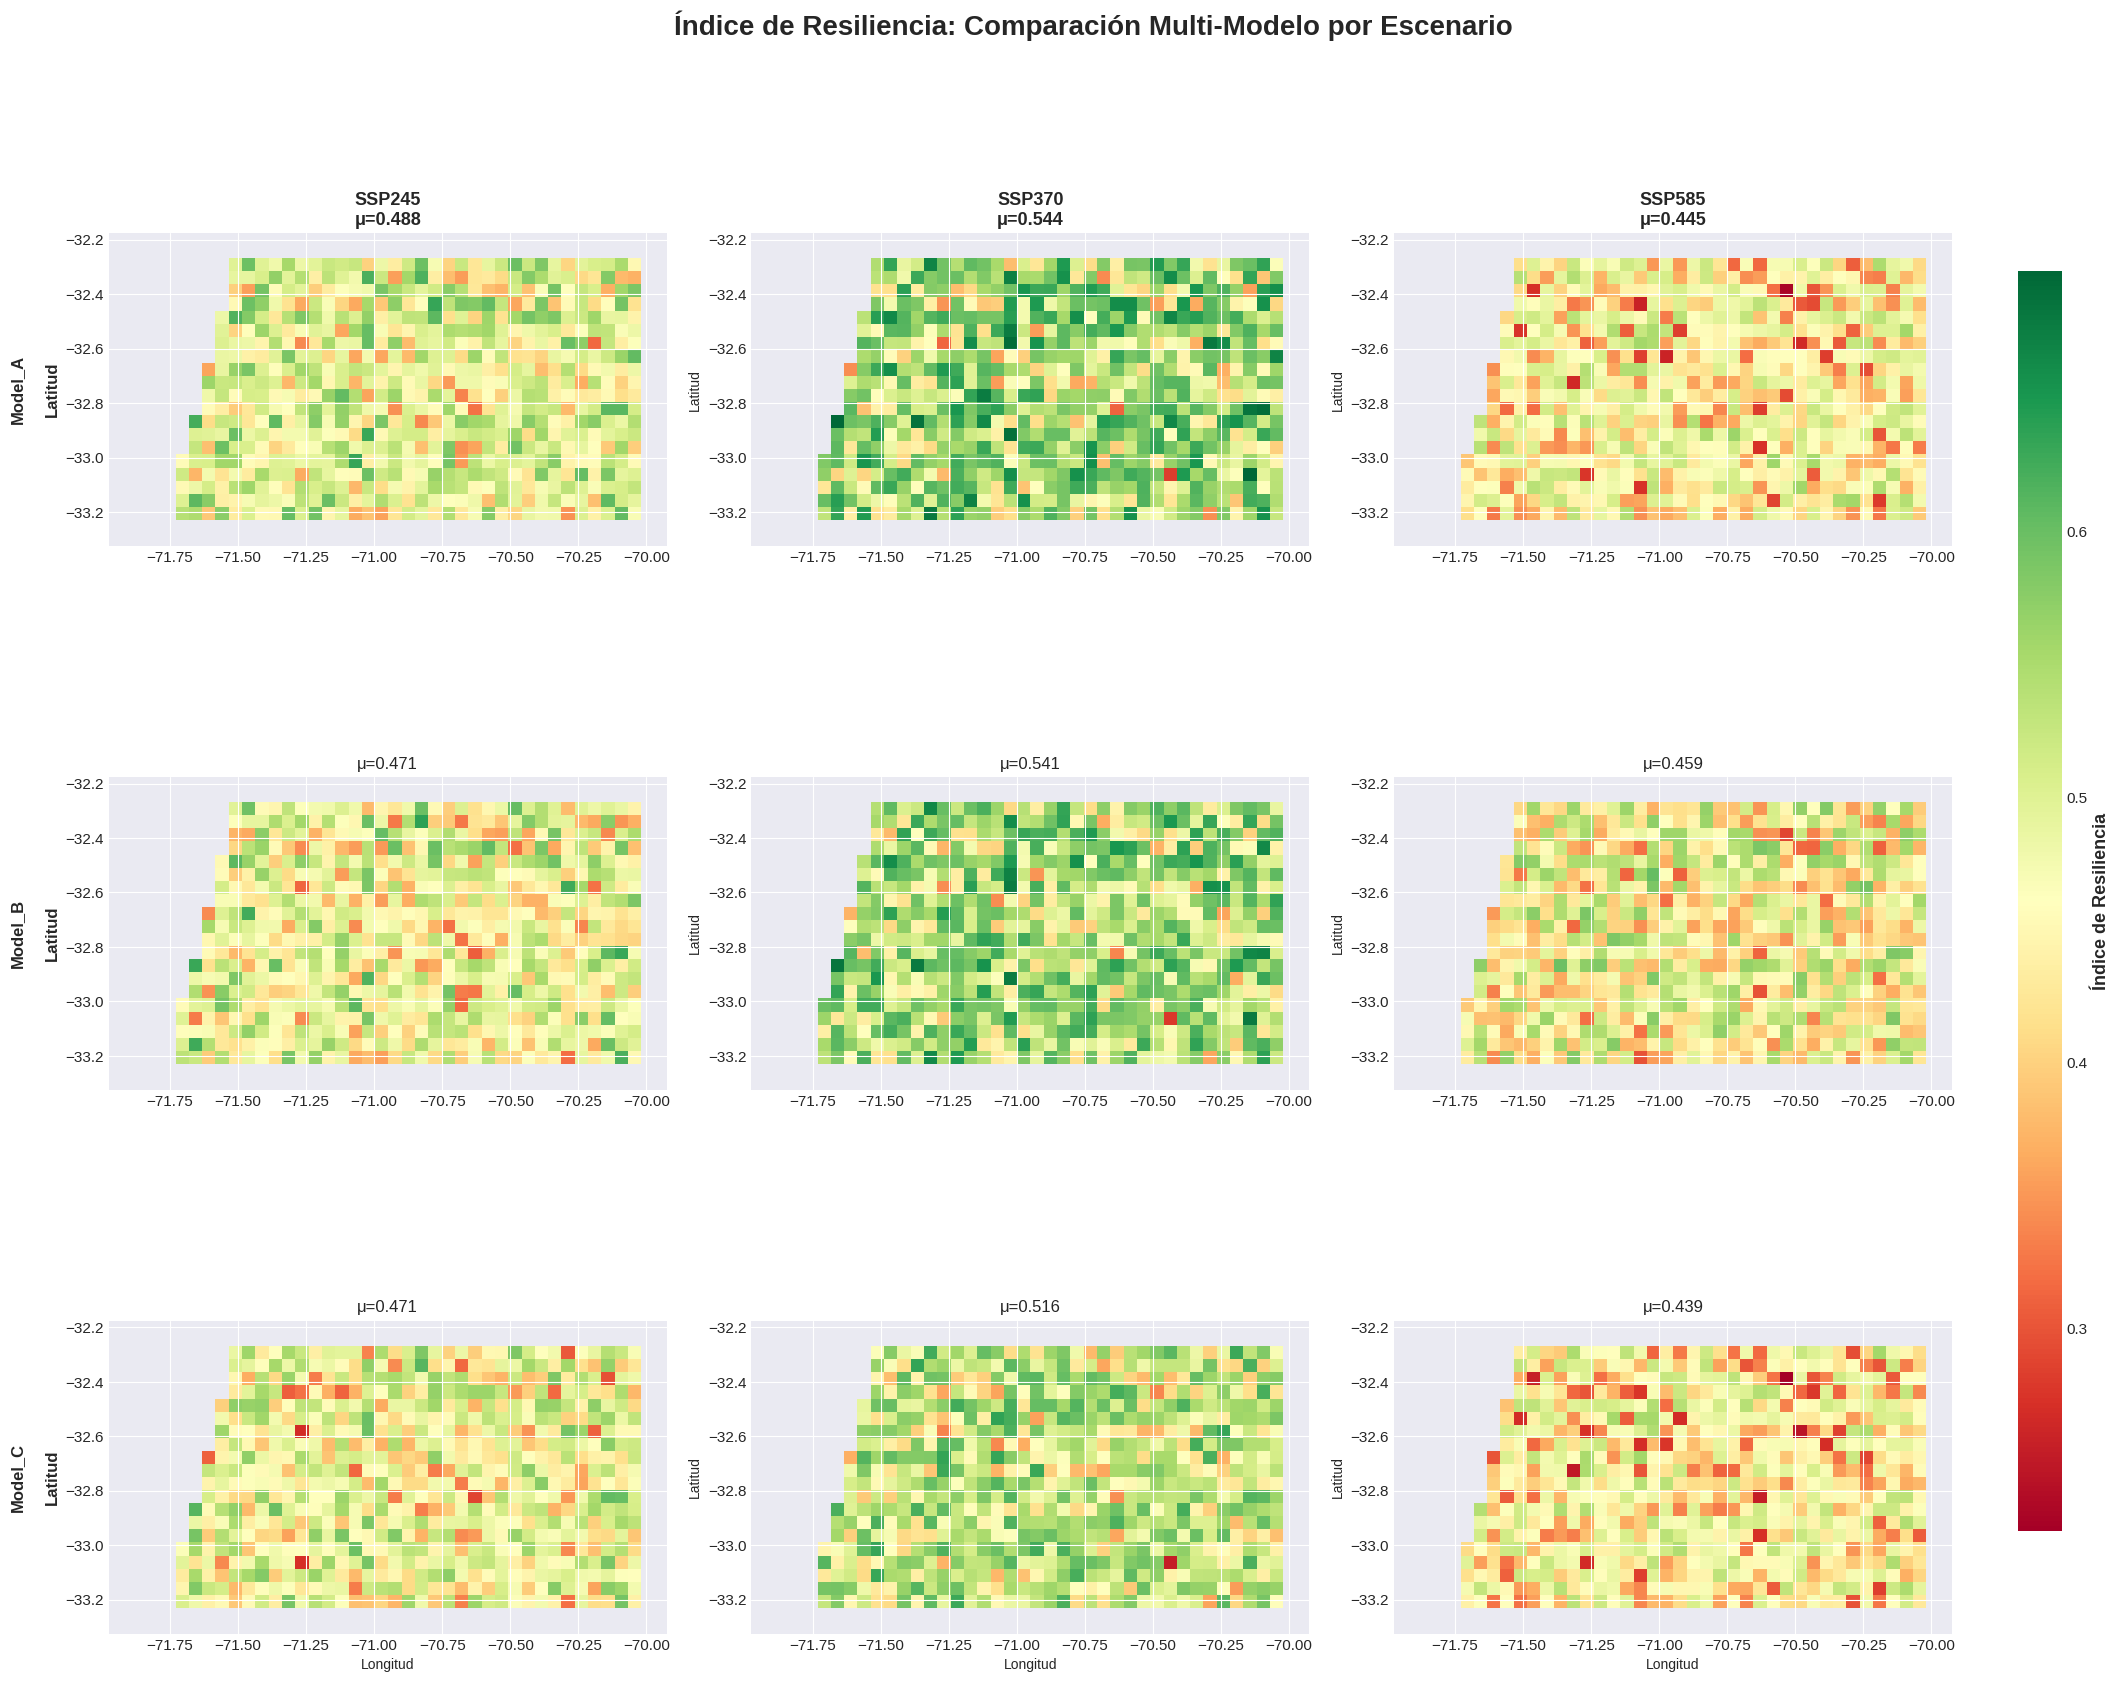

In [11]:
# ===== MAPAS COMPARATIVOS: 3 MODELOS × 3 ESCENARIOS =====
print(f"\n{'='*80}")
print(f"🗺️  GENERANDO MAPAS COMPARATIVOS MULTI-MODELO")
print(f"{'='*80}\n")

# Crear figura con subplots (3 modelos × 3 escenarios = 9 paneles)
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle('Índice de Resiliencia: Comparación Multi-Modelo por Escenario',
             fontsize=20, fontweight='bold', y=0.995)

# Colormap para resiliencia
cmap_resilience = plt.cm.RdYlGn

# Valores min/max globales para escala consistente
all_resilience_values = []
for model in MODELS:
    for scenario in SCENARIOS:
        all_resilience_values.extend(resilience_results[model][scenario]['resilience_index'])

vmin_global = np.min(all_resilience_values)
vmax_global = np.max(all_resilience_values)

print(f"Rango global de resiliencia: [{vmin_global:.3f}, {vmax_global:.3f}]\n")

# Generar mapas
for i, model in enumerate(MODELS):
    for j, scenario in enumerate(SCENARIOS):
        ax = axes[i, j]
        
        # Obtener datos
        resilience_data = resilience_results[model][scenario]['resilience_index']
        resilience_map = create_spatial_map(resilience_data, MASK, GRID_SHAPE)
        
        # Plotear
        im = ax.imshow(resilience_map, cmap=cmap_resilience, 
                      vmin=vmin_global, vmax=vmax_global,
                      extent=EXTENT, origin='lower', interpolation='nearest')
        
        # Título
        if i == 0:
            ax.set_title(f'{scenario.upper()}\nμ={resilience_data.mean():.3f}',
                        fontsize=13, fontweight='bold')
        else:
            ax.set_title(f'μ={resilience_data.mean():.3f}',
                        fontsize=12)
        
        # Etiqueta del modelo (izquierda)
        if j == 0:
            ax.set_ylabel(f'{model}\n\nLatitud', fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel('Latitud', fontsize=10)
        
        # Etiqueta del eje x (solo fila inferior)
        if i == 2:
            ax.set_xlabel('Longitud', fontsize=10)
        
        print(f"   ✓ {model} - {scenario.upper()}: μ={resilience_data.mean():.3f}, "
              f"σ={resilience_data.std():.3f}")

# Colorbar común
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Índice de Resiliencia', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0, 0.9, 0.99])

# Guardar
plot_file = PLOTS_DIR / f'resilience_multimodel_comparison_{MODE}.png'
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"\n✅ Mapa guardado: {plot_file.name}")

plt.show()


🤝 GENERANDO MAPAS DE CONSENSO


SSP245:
   Media consensuada: 0.477 ± 0.060
   Incertidumbre promedio: 0.019
   Max incertidumbre: 0.059

SSP370:
   Media consensuada: 0.534 ± 0.071
   Incertidumbre promedio: 0.022
   Max incertidumbre: 0.083

SSP585:
   Media consensuada: 0.448 ± 0.065
   Incertidumbre promedio: 0.020
   Max incertidumbre: 0.051

✅ Mapa de consenso guardado: resilience_multimodel_consensus_test.png


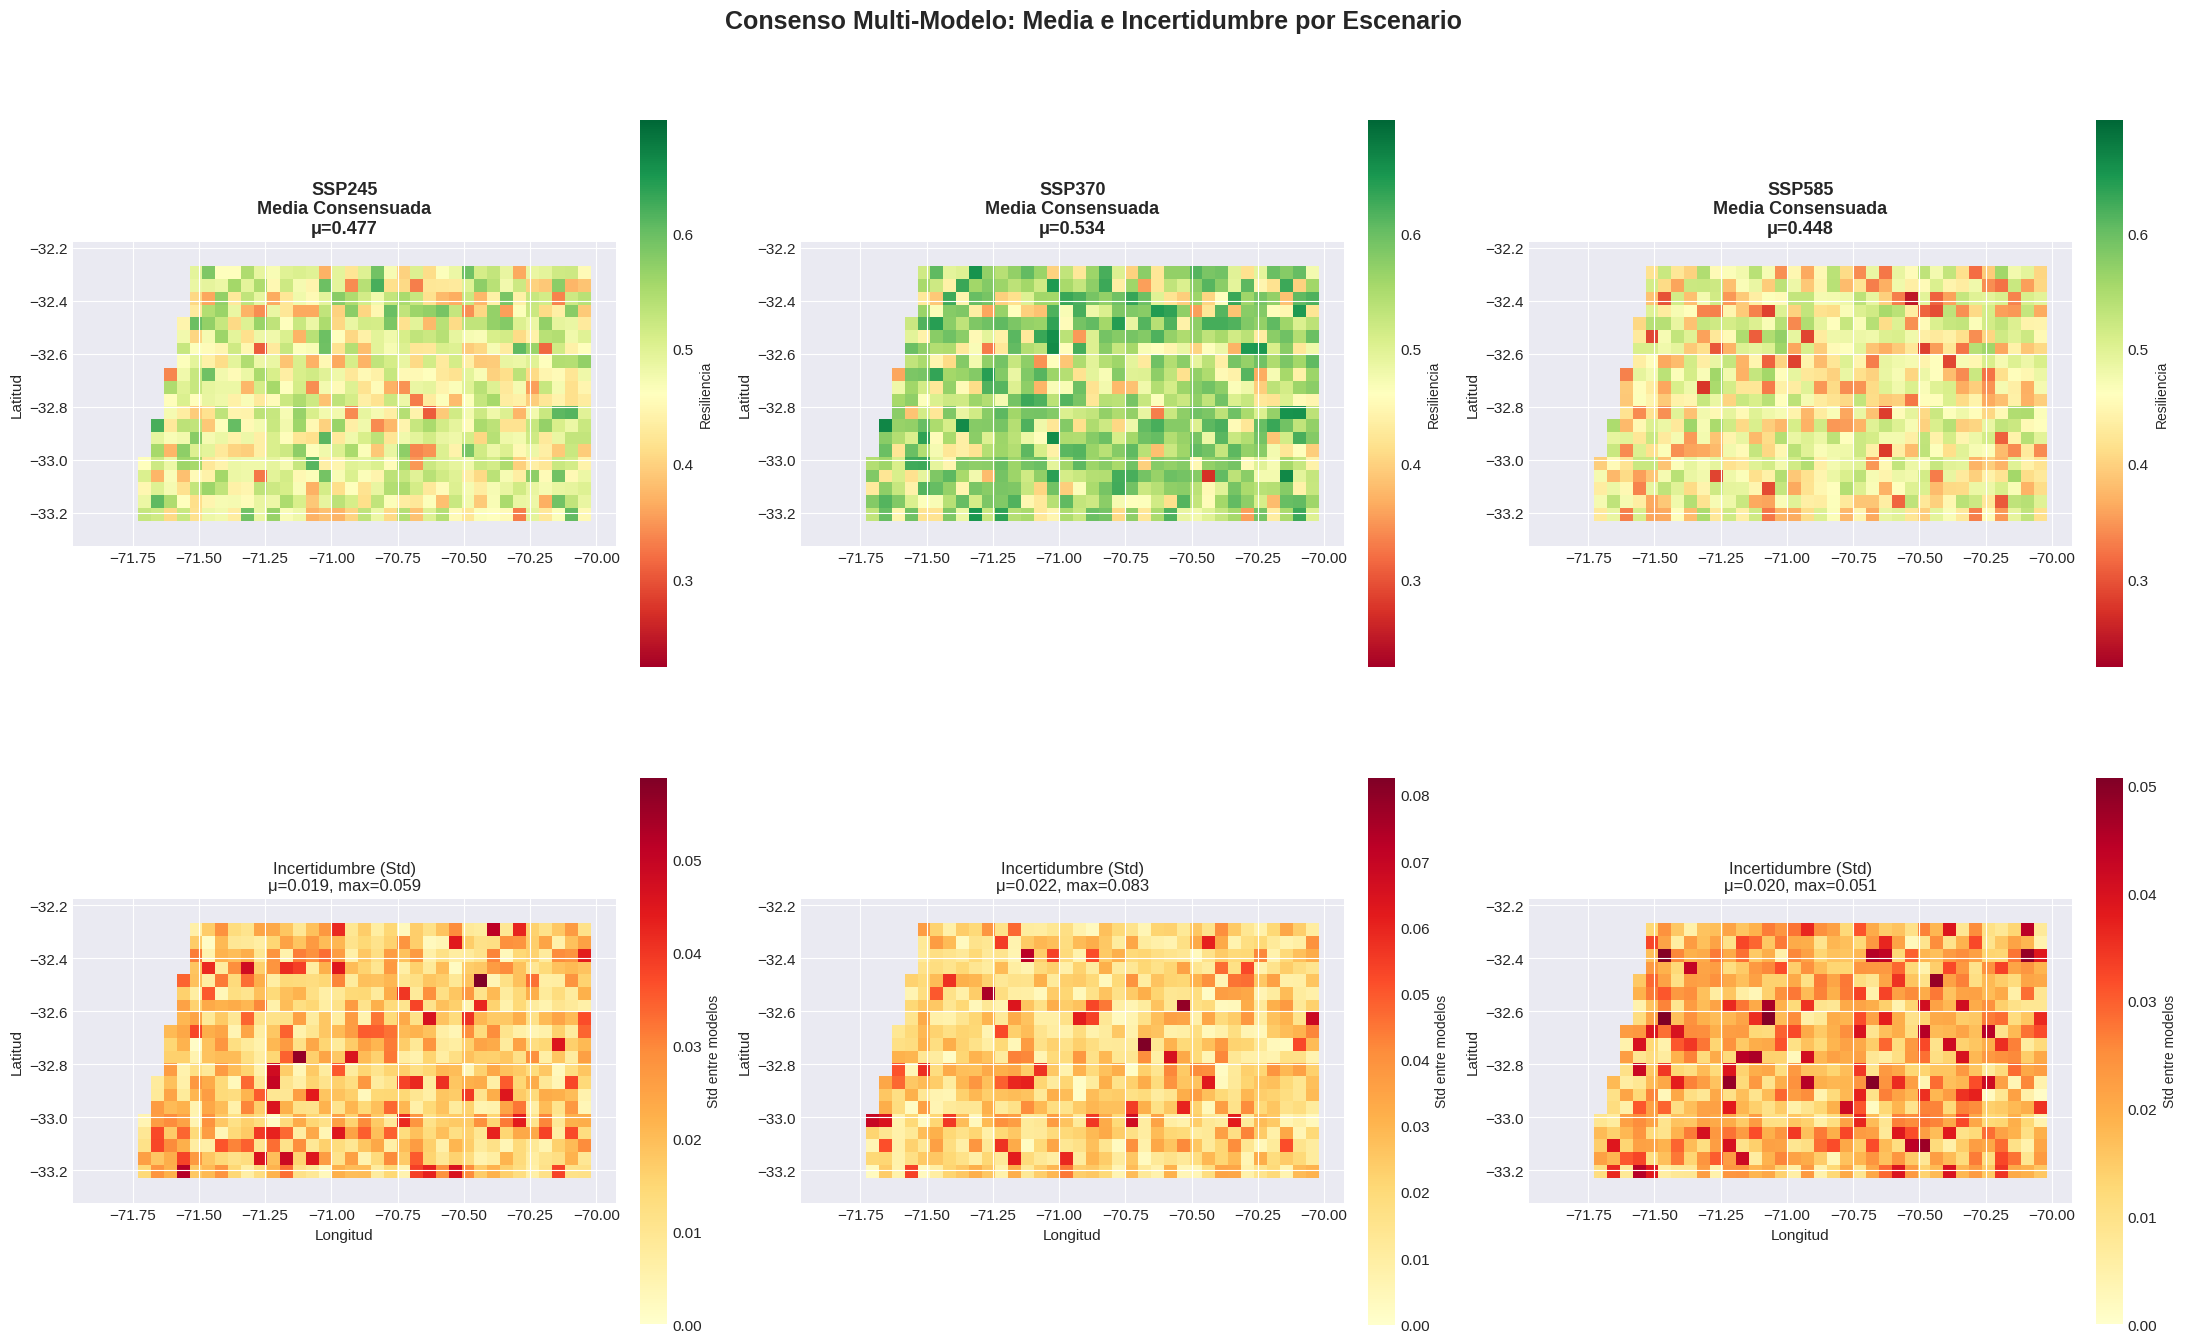

In [12]:
# ===== MAPAS DE CONSENSO ENTRE MODELOS =====
print(f"\n{'='*80}")
print(f"🤝 GENERANDO MAPAS DE CONSENSO")
print(f"{'='*80}\n")

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Consenso Multi-Modelo: Media e Incertidumbre por Escenario',
             fontsize=18, fontweight='bold', y=0.995)

for j, scenario in enumerate(SCENARIOS):
    # Mapa de media (fila 0)
    ax_mean = axes[0, j]
    mean_data = consensus_results[scenario]['mean']
    mean_map = create_spatial_map(mean_data, MASK, GRID_SHAPE)
    
    im_mean = ax_mean.imshow(mean_map, cmap=cmap_resilience,
                             vmin=vmin_global, vmax=vmax_global,
                             extent=EXTENT, origin='lower', interpolation='nearest')
    
    ax_mean.set_title(f'{scenario.upper()}\nMedia Consensuada\nμ={mean_data.mean():.3f}',
                     fontsize=13, fontweight='bold')
    ax_mean.set_ylabel('Latitud', fontsize=11)
    
    cbar_mean = plt.colorbar(im_mean, ax=ax_mean, fraction=0.046, pad=0.04)
    cbar_mean.set_label('Resiliencia', fontsize=10)
    
    # Mapa de incertidumbre (fila 1)
    ax_std = axes[1, j]
    std_data = consensus_results[scenario]['std']
    std_map = create_spatial_map(std_data, MASK, GRID_SHAPE)
    
    im_std = ax_std.imshow(std_map, cmap='YlOrRd',
                           vmin=0, vmax=std_data.max(),
                           extent=EXTENT, origin='lower', interpolation='nearest')
    
    ax_std.set_title(f'Incertidumbre (Std)\nμ={std_data.mean():.3f}, max={std_data.max():.3f}',
                    fontsize=12)
    ax_std.set_xlabel('Longitud', fontsize=11)
    ax_std.set_ylabel('Latitud', fontsize=11)
    
    cbar_std = plt.colorbar(im_std, ax=ax_std, fraction=0.046, pad=0.04)
    cbar_std.set_label('Std entre modelos', fontsize=10)
    
    print(f"\n{scenario.upper()}:")
    print(f"   Media consensuada: {mean_data.mean():.3f} ± {mean_data.std():.3f}")
    print(f"   Incertidumbre promedio: {std_data.mean():.3f}")
    print(f"   Max incertidumbre: {std_data.max():.3f}")

plt.tight_layout()

# Guardar
plot_file = PLOTS_DIR / f'resilience_multimodel_consensus_{MODE}.png'
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"\n✅ Mapa de consenso guardado: {plot_file.name}")

plt.show()

---
## 5️⃣ Análisis de Componentes del Índice de Resiliencia

Comparar los 4 componentes (cohesión, favorabilidad, estabilidad, exposición) entre modelos y escenarios.

In [17]:
# ===== DIAGNÓSTICO: VERIFICAR COMPONENTES DISPONIBLES =====
print(f"\n{'='*80}")
print(f"🔍 DIAGNÓSTICO DE COMPONENTES DISPONIBLES")
print(f"{'='*80}\n")

# Verificar qué keys están disponibles en resilience_results
print("Estructura de resilience_results:")
for model in MODELS:
    print(f"\n{model}:")
    for scenario in SCENARIOS:
        print(f"  {scenario}:")
        keys = list(resilience_results[model][scenario].keys())
        print(f"    Keys disponibles: {keys}")
        
        # Mostrar tamaños
        for key in keys:
            value = resilience_results[model][scenario][key]
            if isinstance(value, np.ndarray):
                print(f"      {key}: array shape {value.shape}")
            else:
                print(f"      {key}: type {type(value).__name__}")

print(f"\n{'='*80}")


🔍 DIAGNÓSTICO DE COMPONENTES DISPONIBLES

Estructura de resilience_results:

Model_A:
  ssp245:
    Keys disponibles: ['components', 'resilience_index', 'labels', 'mean_resilience', 'std_resilience', 'min_resilience', 'max_resilience']
      components: type dict
      resilience_index: array shape (661,)
      labels: array shape (661,)
      mean_resilience: type float64
      std_resilience: type float64
      min_resilience: type float64
      max_resilience: type float64
  ssp370:
    Keys disponibles: ['components', 'resilience_index', 'labels', 'mean_resilience', 'std_resilience', 'min_resilience', 'max_resilience']
      components: type dict
      resilience_index: array shape (661,)
      labels: array shape (661,)
      mean_resilience: type float64
      std_resilience: type float64
      min_resilience: type float64
      max_resilience: type float64
  ssp585:
    Keys disponibles: ['components', 'resilience_index', 'labels', 'mean_resilience', 'std_resilience', 'min_resi


📊 ANÁLISIS DE COMPONENTES DEL ÍNDICE

🔍 Detectando componentes disponibles...
   Componentes encontrados: ['cohesion', 'estabilidad_cluster', 'exposicion_inv', 'favorabilidad']


Cohesión (25%):

   Model_A SSP245: μ=0.470     Model_B SSP245: μ=0.432     Model_C SSP245: μ=0.436  
   Model_A SSP370: μ=0.526     Model_B SSP370: μ=0.507     Model_C SSP370: μ=0.553  
   Model_A SSP585: μ=0.446     Model_B SSP585: μ=0.464     Model_C SSP585: μ=0.450  

Estabilidad_cluster (25%):

   Model_A SSP245: μ=0.759     Model_B SSP245: μ=0.722     Model_C SSP245: μ=0.717  
   Model_A SSP370: μ=0.720     Model_B SSP370: μ=0.729     Model_C SSP370: μ=0.547  
   Model_A SSP585: μ=0.585     Model_B SSP585: μ=0.630     Model_C SSP585: μ=0.550  

Exposición (inv) (15%):

   Model_A SSP245: μ=0.293     Model_B SSP245: μ=0.293     Model_C SSP245: μ=0.293  
   Model_A SSP370: μ=0.456     Model_B SSP370: μ=0.456     Model_C SSP370: μ=0.456  
   Model_A SSP585: μ=0.268     Model_B SSP585: μ=0.268     Model_C S

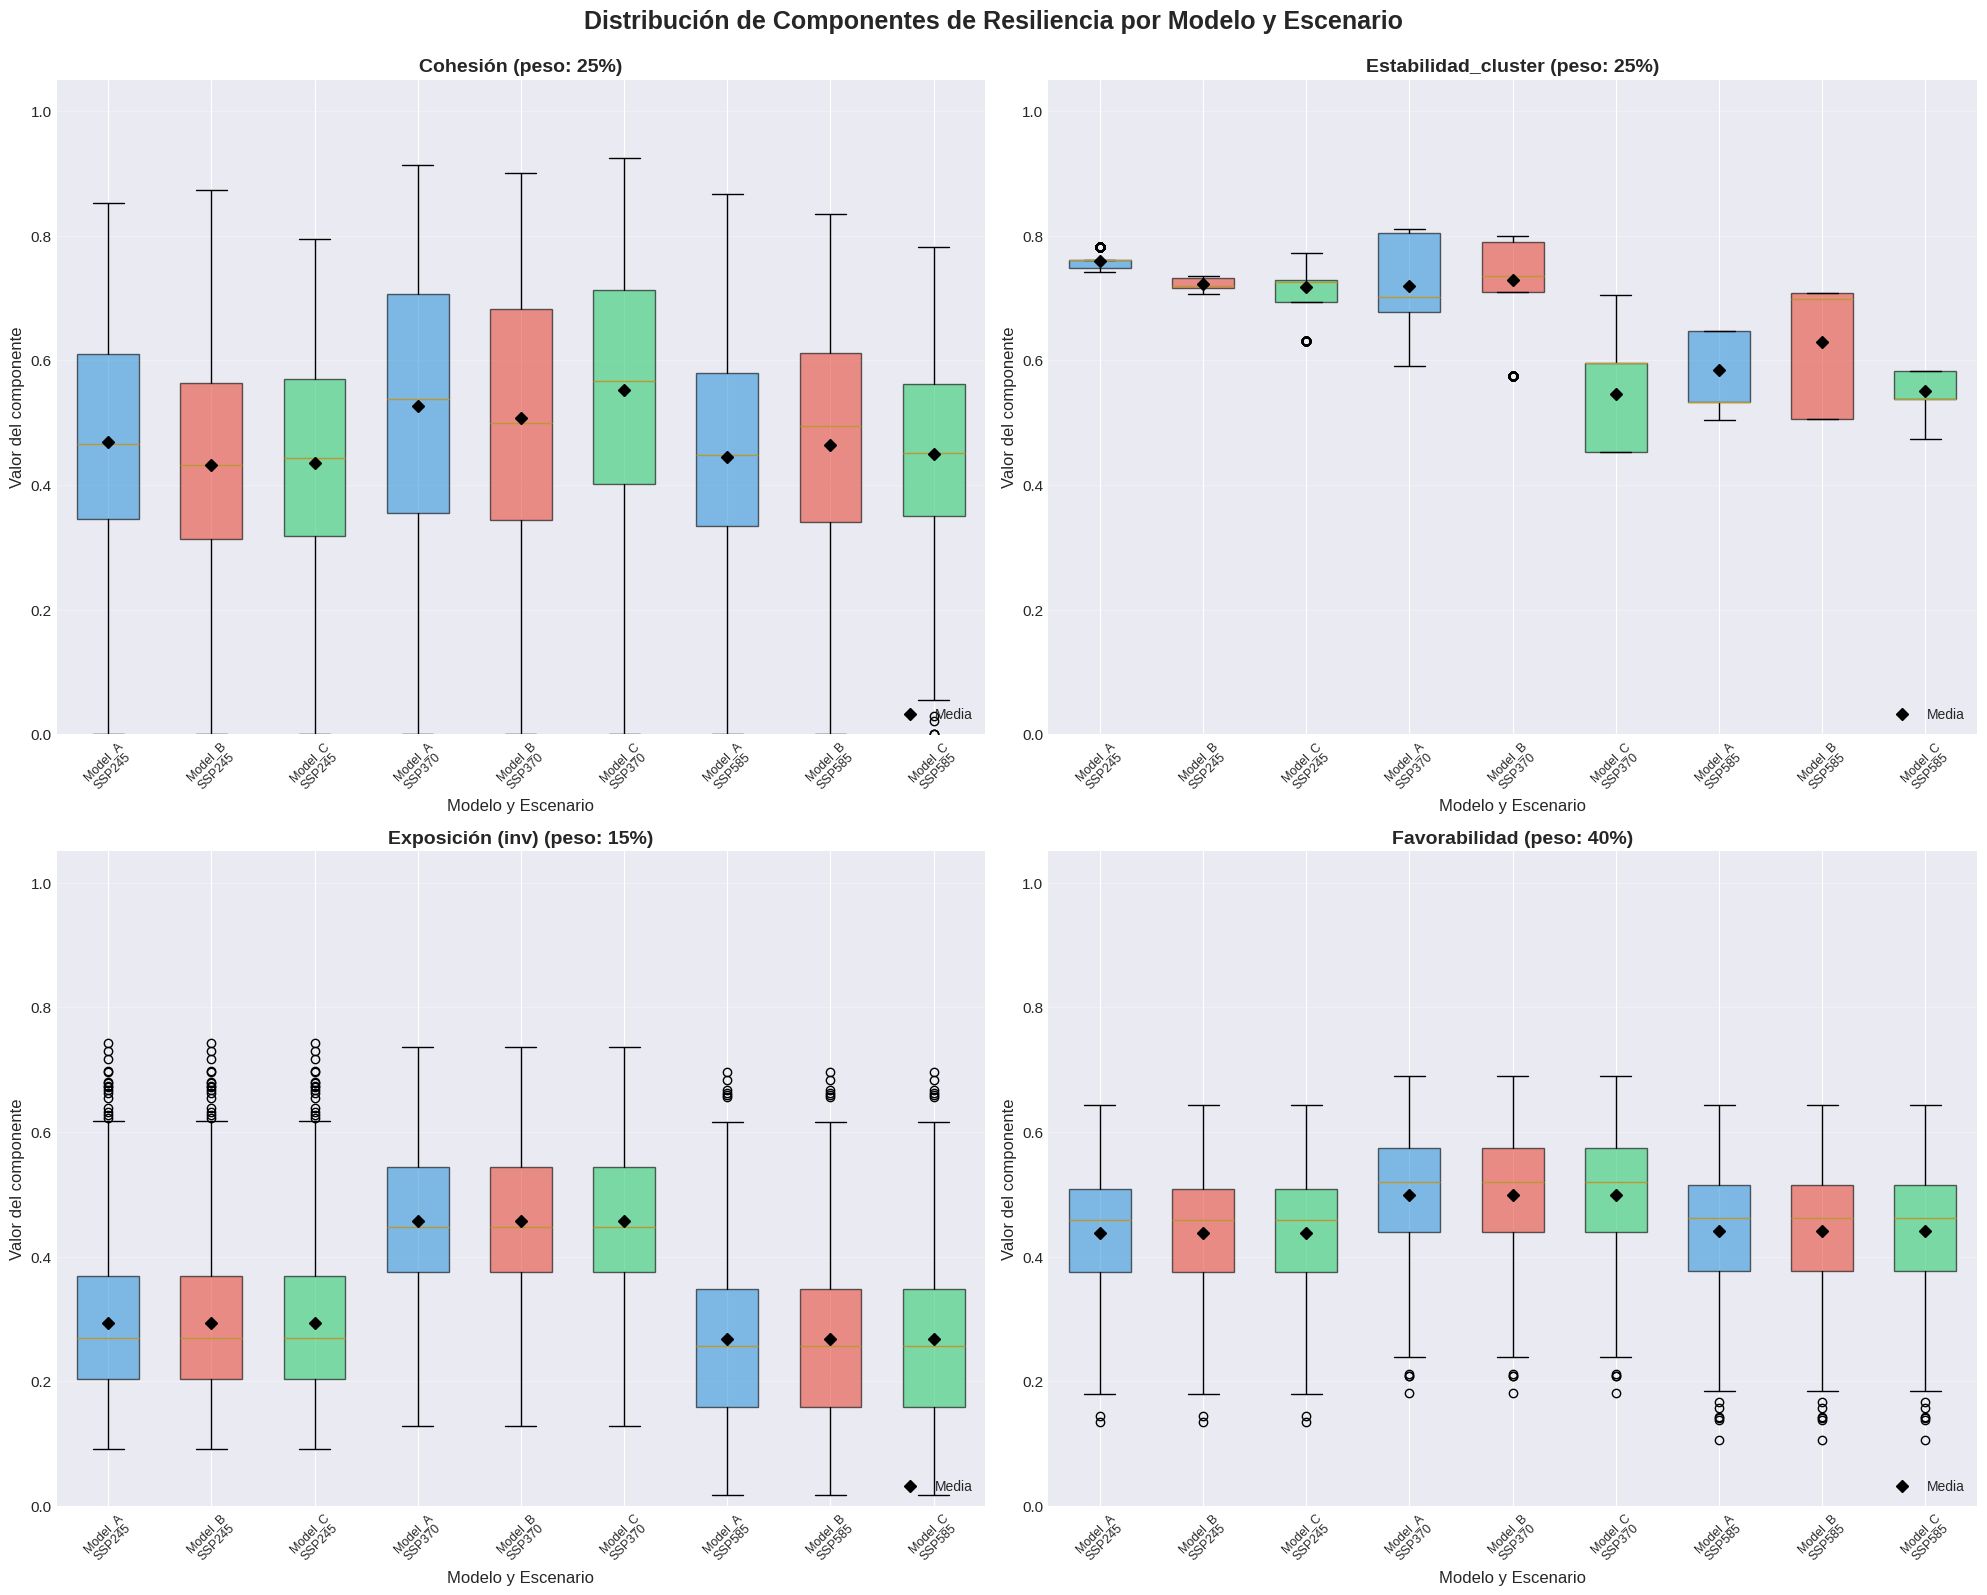

In [19]:
# ===== COMPARACIÓN DE COMPONENTES ENTRE MODELOS =====
print(f"\n{'='*80}")
print(f"📊 ANÁLISIS DE COMPONENTES DEL ÍNDICE")
print(f"{'='*80}\n")

# Detectar automáticamente qué componentes están disponibles
# Los componentes están anidados en resilience_results[model][scenario]['components']
print("🔍 Detectando componentes disponibles...")
available_components = set()
for model in MODELS:
    for scenario in SCENARIOS:
        if 'components' in resilience_results[model][scenario]:
            components_dict = resilience_results[model][scenario]['components']
            for key in components_dict.keys():
                available_components.add(key)

print(f"   Componentes encontrados: {sorted(available_components)}\n")

if len(available_components) == 0:
    print("⚠️  No se encontraron componentes en los resultados.")
    print("   El índice de resiliencia está disponible, pero no sus componentes individuales.\n")
else:
    # Mapeo de nombres de componentes a etiquetas legibles
    component_label_map = {
        'cohesion': ('Cohesión', 0.25),
        'favorabilidad': ('Favorabilidad', 0.40),
        'estabilidad': ('Estabilidad', 0.20),
        'exposicion_inv': ('Exposición (inv)', 0.15),
    }
    
    # Preparar lista de componentes a plotear
    components_to_plot = []
    for comp in sorted(available_components):
        if comp in component_label_map:
            label, weight = component_label_map[comp]
            components_to_plot.append((comp, label, weight))
        else:
            # Componente no mapeado, usar nombre genérico
            components_to_plot.append((comp, comp.capitalize(), 0.25))
    
    # Calcular número de subplots necesarios
    n_components = len(components_to_plot)
    n_rows = (n_components + 1) // 2
    n_cols = min(2, n_components)
    
    # Crear figura
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8*n_rows))
    if n_components == 1:
        axes = np.array([axes])
    elif n_rows == 1:
        axes = np.array(axes).reshape(1, -1)
    axes = axes.flatten()
    
    fig.suptitle('Distribución de Componentes de Resiliencia por Modelo y Escenario',
                 fontsize=18, fontweight='bold', y=0.995)
    
    model_colors = {'Model_A': '#3498db', 'Model_B': '#e74c3c', 'Model_C': '#2ecc71'}
    
    for idx, (component, label, weight) in enumerate(components_to_plot):
        ax = axes[idx]
        
        # Preparar datos para boxplot
        box_data = []
        box_labels = []
        box_colors = []
        
        for scenario in SCENARIOS:
            for model in MODELS:
                # Acceder a los componentes desde el dict anidado
                if 'components' in resilience_results[model][scenario]:
                    components_dict = resilience_results[model][scenario]['components']
                    if component in components_dict:
                        data = components_dict[component]
                        box_data.append(data)
                        box_labels.append(f'{model}\n{scenario.upper()}')
                        box_colors.append(model_colors[model])
        
        if len(box_data) == 0:
            ax.text(0.5, 0.5, f'Sin datos para {label}',
                   ha='center', va='center', fontsize=14)
            ax.set_title(f'{label} (peso: {weight:.0%})', fontsize=14, fontweight='bold')
            continue
        
        # Boxplot
        bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.6)
        
        # Colorear boxes
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        
        ax.set_title(f'{label} (peso: {weight:.0%})', fontsize=14, fontweight='bold')
        ax.set_ylabel('Valor del componente', fontsize=12)
        ax.set_xlabel('Modelo y Escenario', fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim([0, 1.05])
        
        # Rotar labels
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        
        # Calcular medias
        means = [np.mean(d) for d in box_data]
        ax.plot(range(1, len(means)+1), means, 'D', color='black',
                markersize=6, label='Media', zorder=3)
        
        ax.legend(loc='lower right', fontsize=10)
        
        print(f"\n{label} ({weight:.0%}):")
        for i, (data, label_txt) in enumerate(zip(box_data, box_labels)):
            if i % 3 == 0:  # Nueva línea cada 3 (cada modelo)
                print()
            print(f"   {label_txt.replace(chr(10), ' ')}: μ={np.mean(data):.3f}", end="  ")
        print()
    
    # Ocultar subplots vacíos
    for idx in range(n_components, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    # Guardar
    plot_file = PLOTS_DIR / f'resilience_components_multimodel_{MODE}.png'
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    print(f"\n✅ Gráfico de componentes guardado: {plot_file.name}")
    
    plt.show()

print(f"\n{'='*80}")

---
## 6️⃣ Identificación de Zonas Críticas

Identificar píxeles con alta/baja resiliencia consistente entre modelos.

In [20]:
# ===== IDENTIFICAR ZONAS CRÍTICAS PERSISTENTES =====
print(f"\n{'='*80}")
print(f"🎯 IDENTIFICACIÓN DE ZONAS CRÍTICAS")
print(f"{'='*80}\n")

# Para cada escenario, identificar píxeles resilientes/vulnerables en los 3 modelos
critical_zones = {}

for scenario in SCENARIOS:
    print(f"\n🌍 {scenario.upper()}:")
    
    # Obtener resiliencia de los 3 modelos
    resilience_stack = consensus_results[scenario]['stack']  # (3, n_pixels)
    resilience_mean = consensus_results[scenario]['mean']
    resilience_std = consensus_results[scenario]['std']
    
    # Definir umbrales
    threshold_resilient = np.percentile(resilience_mean, 75)  # Top 25%
    threshold_vulnerable = np.percentile(resilience_mean, 25)  # Bottom 25%
    threshold_consensus_high = 0.05  # Std < 0.05 = alto consenso
    
    # Zonas resilientes con alto consenso (los 3 modelos están de acuerdo)
    resilient_mask = (resilience_mean > threshold_resilient) & (resilience_std < threshold_consensus_high)
    n_resilient = resilient_mask.sum()
    
    # Zonas vulnerables con alto consenso
    vulnerable_mask = (resilience_mean < threshold_vulnerable) & (resilience_std < threshold_consensus_high)
    n_vulnerable = vulnerable_mask.sum()
    
    # Zonas de alta incertidumbre (modelos no concuerdan)
    uncertain_mask = resilience_std > 0.10  # Std > 0.10
    n_uncertain = uncertain_mask.sum()
    
    critical_zones[scenario] = {
        'resilient_mask': resilient_mask,
        'vulnerable_mask': vulnerable_mask,
        'uncertain_mask': uncertain_mask
    }
    
    print(f"   Zonas resilientes (alto consenso): {n_resilient} píxeles ({100*n_resilient/len(resilience_mean):.1f}%)")
    print(f"   Zonas vulnerables (alto consenso): {n_vulnerable} píxeles ({100*n_vulnerable/len(resilience_mean):.1f}%)")
    print(f"   Zonas inciertas (bajo consenso): {n_uncertain} píxeles ({100*n_uncertain/len(resilience_mean):.1f}%)")
    
    # Top 10 píxeles más resilientes
    top_resilient_idx = np.argsort(resilience_mean)[-10:]
    print(f"\n   Top 10 píxeles más resilientes:")
    for idx in top_resilient_idx[::-1]:
        print(f"      Píxel {idx}: μ={resilience_mean[idx]:.3f}, σ={resilience_std[idx]:.4f}")
    
    # Top 10 píxeles más vulnerables
    top_vulnerable_idx = np.argsort(resilience_mean)[:10]
    print(f"\n   Top 10 píxeles más vulnerables:")
    for idx in top_vulnerable_idx:
        print(f"      Píxel {idx}: μ={resilience_mean[idx]:.3f}, σ={resilience_std[idx]:.4f}")

print(f"\n{'='*80}")


🎯 IDENTIFICACIÓN DE ZONAS CRÍTICAS


🌍 SSP245:
   Zonas resilientes (alto consenso): 161 píxeles (24.4%)
   Zonas vulnerables (alto consenso): 165 píxeles (25.0%)
   Zonas inciertas (bajo consenso): 0 píxeles (0.0%)

   Top 10 píxeles más resilientes:
      Píxel 613: μ=0.622, σ=0.0110
      Píxel 243: μ=0.622, σ=0.0079
      Píxel 308: μ=0.614, σ=0.0128
      Píxel 153: μ=0.613, σ=0.0151
      Píxel 222: μ=0.611, σ=0.0185
      Píxel 307: μ=0.608, σ=0.0026
      Píxel 467: μ=0.607, σ=0.0143
      Píxel 36: μ=0.606, σ=0.0181
      Píxel 33: μ=0.605, σ=0.0114
      Píxel 249: μ=0.602, σ=0.0028

   Top 10 píxeles más vulnerables:
      Píxel 297: μ=0.306, σ=0.0150
      Píxel 447: μ=0.307, σ=0.0299
      Píxel 469: μ=0.316, σ=0.0049
      Píxel 114: μ=0.326, σ=0.0397
      Píxel 29: μ=0.329, σ=0.0127
      Píxel 329: μ=0.329, σ=0.0051
      Píxel 616: μ=0.332, σ=0.0167
      Píxel 596: μ=0.335, σ=0.0293
      Píxel 376: μ=0.337, σ=0.0204
      Píxel 195: μ=0.339, σ=0.0062

🌍 SSP370:
   

---
## 7️⃣ Exportar Resultados Consolidados

Guardar análisis de consenso, zonas críticas y métricas comparativas.

In [23]:
# ===== EXPORTAR RESULTADOS CONSOLIDADOS =====
print(f"\n{'='*80}")
print(f"💾 EXPORTANDO RESULTADOS CONSOLIDADOS")
print(f"{'='*80}\n")

# 1. DataFrame con consenso por píxel y escenario
print("📊 Creando DataFrame consolidado...")

consensus_data = []
for scenario in SCENARIOS:
    for pixel_id in range(len(consensus_results[scenario]['mean'])):
        row = {
            'pixel_id': pixel_id,
            'scenario': scenario,
            'resilience_mean': consensus_results[scenario]['mean'][pixel_id],
            'resilience_median': consensus_results[scenario]['median'][pixel_id],
            'resilience_std': consensus_results[scenario]['std'][pixel_id],
            'resilience_min': consensus_results[scenario]['min'][pixel_id],
            'resilience_max': consensus_results[scenario]['max'][pixel_id],
            'resilience_cv': consensus_results[scenario]['cv'][pixel_id],
        }
        
        # Añadir resiliencia de cada modelo
        for model in MODELS:
            row[f'resilience_{model}'] = resilience_results[model][scenario]['resilience_index'][pixel_id]
        
        # Añadir componentes (promediados entre modelos) - acceder desde dict anidado
        # Primero detectar qué componentes están disponibles
        sample_components = resilience_results[MODELS[0]][scenario].get('components', {})
        for component in sample_components.keys():
            component_values = []
            for model in MODELS:
                if 'components' in resilience_results[model][scenario]:
                    components_dict = resilience_results[model][scenario]['components']
                    if component in components_dict:
                        component_values.append(components_dict[component][pixel_id])
            
            if component_values:
                row[f'{component}_mean'] = np.mean(component_values)
        
        consensus_data.append(row)

df_consensus = pd.DataFrame(consensus_data)

# Guardar CSV principal
csv_file = REPORTS_DIR / f'resilience_multimodel_consensus_complete_{MODE}.csv'
df_consensus.to_csv(csv_file, index=False)
print(f"✅ CSV consolidado: {csv_file.name}")
print(f"   {len(df_consensus)} registros ({len(SCENARIOS)} escenarios × {n_valid_pixels} píxeles)")

# 2. Resumen de zonas críticas por escenario
print(f"\n📍 Exportando zonas críticas...")

critical_zones_data = []
for scenario in SCENARIOS:
    for zone_type in ['resilient_mask', 'vulnerable_mask', 'uncertain_mask']:
        mask = critical_zones[scenario][zone_type]
        pixel_ids = np.where(mask)[0]
        
        for pixel_id in pixel_ids:
            critical_zones_data.append({
                'scenario': scenario,
                'zone_type': zone_type.replace('_mask', ''),
                'pixel_id': pixel_id,
                'resilience_mean': consensus_results[scenario]['mean'][pixel_id],
                'resilience_std': consensus_results[scenario]['std'][pixel_id]
            })

df_critical = pd.DataFrame(critical_zones_data)
csv_critical = REPORTS_DIR / f'resilience_multimodel_critical_zones_{MODE}.csv'
df_critical.to_csv(csv_critical, index=False)
print(f"✅ CSV zonas críticas: {csv_critical.name}")
print(f"   {len(df_critical)} píxeles críticos identificados")

# 3. Resumen ejecutivo por escenario y modelo
print(f"\n📋 Exportando resumen ejecutivo...")

summary_data = []
for scenario in SCENARIOS:
    # Consenso
    row_consensus = {
        'type': 'consensus',
        'model': 'ALL',
        'scenario': scenario,
        'resilience_mean': consensus_results[scenario]['mean'].mean(),
        'resilience_std': consensus_results[scenario]['mean'].std(),
        'uncertainty_mean': consensus_results[scenario]['std'].mean(),
        'uncertainty_max': consensus_results[scenario]['std'].max()
    }
    summary_data.append(row_consensus)
    
    # Por modelo
    for model in MODELS:
        resilience_data = resilience_results[model][scenario]['resilience_index']
        row_model = {
            'type': 'individual',
            'model': model,
            'scenario': scenario,
            'resilience_mean': resilience_data.mean(),
            'resilience_std': resilience_data.std(),
            'resilience_min': resilience_data.min(),
            'resilience_max': resilience_data.max()
        }
        summary_data.append(row_model)

df_summary = pd.DataFrame(summary_data)
csv_summary = REPORTS_DIR / f'resilience_multimodel_summary_{MODE}.csv'
df_summary.to_csv(csv_summary, index=False)
print(f"✅ CSV resumen: {csv_summary.name}")
print(f"   {len(df_summary)} filas de resumen")

# 4. Guardar PKL con todos los resultados para análisis posterior
print(f"\n💾 Guardando PKL con resultados completos...")

results_complete = {
    'consensus_results': consensus_results,
    'critical_zones': critical_zones,
    'resilience_results': resilience_results,  # Ya cargado del notebook 04
    'spatial_info': {
        'mask': MASK,
        'grid_shape': GRID_SHAPE,
        'lat_coords': lat_coords,
        'lon_coords': lon_coords,
        'extent': EXTENT,
        'n_valid_pixels': n_valid_pixels
    },
    'config': {
        'models': MODELS,
        'scenarios': SCENARIOS,
        'mode': MODE,
        'n_features': n_features
    }
}

pkl_file = RESULTS_DIR / f'resilience_multimodel_spatial_analysis_{MODE}.pkl'
with open(pkl_file, 'wb') as f:
    pickle.dump(results_complete, f)
print(f"✅ PKL completo: {pkl_file.name}")

# Resumen final
print(f"\n{'='*80}")
print(f"📊 RESUMEN FINAL - NOTEBOOK 05")
print(f"{'='*80}")
print(f"\n🔢 Modelos analizados: {', '.join(MODELS)}")
print(f"🌍 Escenarios: {', '.join([s.upper() for s in SCENARIOS])}")
print(f"📍 Píxeles válidos: {n_valid_pixels}")

print(f"\n📈 Resiliencia Consensuada (Media ± Incertidumbre):")
for scenario in SCENARIOS:
    mean_resilience = consensus_results[scenario]['mean'].mean()
    mean_uncertainty = consensus_results[scenario]['std'].mean()
    print(f"   {scenario.upper()}: {mean_resilience:.3f} ± {mean_uncertainty:.4f}")

print(f"\n📁 Archivos exportados:")
print(f"   • {csv_file.name} ({len(df_consensus)} registros)")
print(f"   • {csv_critical.name} ({len(df_critical)} píxeles críticos)")
print(f"   • {csv_summary.name} ({len(df_summary)} filas)")
print(f"   • {pkl_file.name}")
print(f"   • resilience_multimodel_comparison_{MODE}.png")
print(f"   • resilience_multimodel_consensus_{MODE}.png")
print(f"   • resilience_components_multimodel_{MODE}.png")

print(f"\n{'='*80}")
print(f"✅ NOTEBOOK 05 COMPLETADO")
print(f"{'='*80}")


💾 EXPORTANDO RESULTADOS CONSOLIDADOS

📊 Creando DataFrame consolidado...
✅ CSV consolidado: resilience_multimodel_consensus_complete_test.csv
   1983 registros (3 escenarios × 661 píxeles)

📍 Exportando zonas críticas...
✅ CSV zonas críticas: resilience_multimodel_critical_zones_test.csv
   967 píxeles críticos identificados

📋 Exportando resumen ejecutivo...
✅ CSV resumen: resilience_multimodel_summary_test.csv
   12 filas de resumen

💾 Guardando PKL con resultados completos...
✅ PKL completo: resilience_multimodel_spatial_analysis_test.pkl

📊 RESUMEN FINAL - NOTEBOOK 05

🔢 Modelos analizados: Model_A, Model_B, Model_C
🌍 Escenarios: SSP245, SSP370, SSP585
📍 Píxeles válidos: 661

📈 Resiliencia Consensuada (Media ± Incertidumbre):
   SSP245: 0.477 ± 0.0186
   SSP370: 0.534 ± 0.0223
   SSP585: 0.448 ± 0.0203

📁 Archivos exportados:
   • resilience_multimodel_consensus_complete_test.csv (1983 registros)
   • resilience_multimodel_critical_zones_test.csv (967 píxeles críticos)
   • resili

---
## 8️⃣ Validación del Índice de Resiliencia

Verificar la coherencia y robustez del índice calculado mediante múltiples pruebas de validación.

In [30]:
# ===== VALIDACIÓN 1: COHERENCIA INTER-MODELO =====
print(f"\n{'='*80}")
print(f"✅ VALIDACIÓN 1: COHERENCIA ENTRE MODELOS")
print(f"{'='*80}\n")

print("📊 Correlaciones entre modelos por escenario:")
print("=" * 60)

for scenario in SCENARIOS:
    print(f"\n{scenario.upper()}:")
    
    # Calcular correlaciones entre todos los pares de modelos
    from itertools import combinations
    for model1, model2 in combinations(MODELS, 2):
        r1 = resilience_results[model1][scenario]['resilience_index']
        r2 = resilience_results[model2][scenario]['resilience_index']
        
        corr_pearson = np.corrcoef(r1, r2)[0, 1]
        
        # Spearman (rankings)
        from scipy.stats import spearmanr
        corr_spearman, _ = spearmanr(r1, r2)
        
        print(f"   {model1} vs {model2}:")
        print(f"      Pearson: {corr_pearson:.3f}")
        print(f"      Spearman: {corr_spearman:.3f}")

# Criterio: correlación > 0.7 = buena coherencia
print(f"\n✅ Criterio de éxito: Correlación > 0.7 entre modelos")
print(f"   Si los 3 modelos tienen arquitecturas diferentes pero correlación alta,")
print(f"   indica que el índice captura patrones robustos, no artefactos del modelo.")

print(f"\n{'='*80}")


✅ VALIDACIÓN 1: COHERENCIA ENTRE MODELOS

📊 Correlaciones entre modelos por escenario:

SSP245:
   Model_A vs Model_B:
      Pearson: 0.959
      Spearman: 0.955
   Model_A vs Model_C:
      Pearson: 0.784
      Spearman: 0.760
   Model_B vs Model_C:
      Pearson: 0.818
      Spearman: 0.792

SSP370:
   Model_A vs Model_B:
      Pearson: 0.951
      Spearman: 0.940
   Model_A vs Model_C:
      Pearson: 0.824
      Spearman: 0.759
   Model_B vs Model_C:
      Pearson: 0.805
      Spearman: 0.733

SSP585:
   Model_A vs Model_B:
      Pearson: 0.801
      Spearman: 0.809
   Model_A vs Model_C:
      Pearson: 0.938
      Spearman: 0.913
   Model_B vs Model_C:
      Pearson: 0.844
      Spearman: 0.860

✅ Criterio de éxito: Correlación > 0.7 entre modelos
   Si los 3 modelos tienen arquitecturas diferentes pero correlación alta,
   indica que el índice captura patrones robustos, no artefactos del modelo.



In [31]:
# ===== VALIDACIÓN 2: COHERENCIA DE COMPONENTES =====
print(f"\n{'='*80}")
print(f"✅ VALIDACIÓN 2: COHERENCIA DE COMPONENTES")
print(f"{'='*80}\n")

print("📊 Verificar que los componentes están bien balanceados:")
print("=" * 60)

# Obtener nombres de componentes
sample_components = resilience_results[MODELS[0]][SCENARIOS[0]].get('components', {})
component_names = list(sample_components.keys())

for scenario in SCENARIOS:
    print(f"\n{scenario.upper()}:")
    
    for component in component_names:
        # Recolectar valores de todos los modelos
        all_values = []
        for model in MODELS:
            if 'components' in resilience_results[model][scenario]:
                comp_dict = resilience_results[model][scenario]['components']
                if component in comp_dict:
                    all_values.extend(comp_dict[component])
        
        if all_values:
            mean_val = np.mean(all_values)
            std_val = np.std(all_values)
            min_val = np.min(all_values)
            max_val = np.max(all_values)
            
            print(f"   {component}:")
            print(f"      μ={mean_val:.3f}, σ={std_val:.3f}, rango=[{min_val:.3f}, {max_val:.3f}]")

print(f"\n✅ Criterios de éxito:")
print(f"   1. Todos los componentes deben estar en [0, 1]")
print(f"   2. No debe haber componentes con varianza ~0 (sin información)")
print(f"   3. No debe haber dominancia excesiva de un componente")

print(f"\n{'='*80}")


✅ VALIDACIÓN 2: COHERENCIA DE COMPONENTES

📊 Verificar que los componentes están bien balanceados:

SSP245:
   cohesion:
      μ=0.446, σ=0.180, rango=[0.000, 0.873]
   favorabilidad:
      μ=0.438, σ=0.097, rango=[0.134, 0.643]
   estabilidad_cluster:
      μ=0.733, σ=0.032, rango=[0.631, 0.781]
   exposicion_inv:
      μ=0.293, σ=0.126, rango=[0.092, 0.742]

SSP370:
   cohesion:
      μ=0.529, σ=0.217, rango=[0.000, 0.925]
   favorabilidad:
      μ=0.500, σ=0.100, rango=[0.182, 0.689]
   estabilidad_cluster:
      μ=0.665, σ=0.118, rango=[0.453, 0.811]
   exposicion_inv:
      μ=0.456, σ=0.103, rango=[0.129, 0.735]

SSP585:
   cohesion:
      μ=0.453, σ=0.173, rango=[0.000, 0.866]
   favorabilidad:
      μ=0.441, σ=0.105, rango=[0.105, 0.644]
   estabilidad_cluster:
      μ=0.588, σ=0.076, rango=[0.475, 0.708]
   exposicion_inv:
      μ=0.268, σ=0.133, rango=[0.017, 0.696]

✅ Criterios de éxito:
   1. Todos los componentes deben estar en [0, 1]
   2. No debe haber componentes con va

In [32]:
# ===== VALIDACIÓN 3: SENSIBILIDAD A ESCENARIOS CLIMÁTICOS =====
print(f"\n{'='*80}")
print(f"✅ VALIDACIÓN 3: RESPUESTA A ESCENARIOS CLIMÁTICOS")
print(f"{'='*80}\n")

print("📊 Verificar que el índice responde coherentemente a escenarios:")
print("=" * 60)

# Analizar tendencias entre escenarios
print(f"\n1. Cambios promedio de resiliencia entre escenarios:")
print(f"   (Esperado: SSP585 debería tener cambios más extremos que SSP370)")

for model in MODELS:
    print(f"\n{model}:")
    r_245 = resilience_results[model]['ssp245']['resilience_index']
    r_370 = resilience_results[model]['ssp370']['resilience_index']
    r_585 = resilience_results[model]['ssp585']['resilience_index']
    
    delta_370 = np.mean(r_370 - r_245)
    delta_585 = np.mean(r_585 - r_245)
    
    print(f"   Δ(SSP370 - SSP245): {delta_370:+.3f}")
    print(f"   Δ(SSP585 - SSP245): {delta_585:+.3f}")
    
    # Porcentaje de píxeles que cambian consistentemente
    consistent_decline = ((r_370 < r_245) & (r_585 < r_370)).sum()
    consistent_improve = ((r_370 > r_245) & (r_585 > r_370)).sum()
    
    print(f"   Píxeles con declive consistente: {consistent_decline} ({100*consistent_decline/len(r_245):.1f}%)")
    print(f"   Píxeles con mejora consistente: {consistent_improve} ({100*consistent_improve/len(r_245):.1f}%)")

print(f"\n✅ Criterios de éxito:")
print(f"   1. SSP585 debe mostrar cambios más pronunciados que SSP370")
print(f"   2. Debe haber patrones de cambio consistentes (no aleatorios)")
print(f"   3. La dirección del cambio debe ser interpretable climáticamente")

print(f"\n{'='*80}")


✅ VALIDACIÓN 3: RESPUESTA A ESCENARIOS CLIMÁTICOS

📊 Verificar que el índice responde coherentemente a escenarios:

1. Cambios promedio de resiliencia entre escenarios:
   (Esperado: SSP585 debería tener cambios más extremos que SSP370)

Model_A:
   Δ(SSP370 - SSP245): +0.056
   Δ(SSP585 - SSP245): -0.043
   Píxeles con declive consistente: 82 (12.4%)
   Píxeles con mejora consistente: 11 (1.7%)

Model_B:
   Δ(SSP370 - SSP245): +0.069
   Δ(SSP585 - SSP245): -0.013
   Píxeles con declive consistente: 40 (6.1%)
   Píxeles con mejora consistente: 7 (1.1%)

Model_C:
   Δ(SSP370 - SSP245): +0.044
   Δ(SSP585 - SSP245): -0.032
   Píxeles con declive consistente: 144 (21.8%)
   Píxeles con mejora consistente: 0 (0.0%)

✅ Criterios de éxito:
   1. SSP585 debe mostrar cambios más pronunciados que SSP370
   2. Debe haber patrones de cambio consistentes (no aleatorios)
   3. La dirección del cambio debe ser interpretable climáticamente



In [37]:
# ===== VALIDACIÓN 4: COHERENCIA ESPACIAL =====
print(f"\n{'='*80}")
print(f"✅ VALIDACIÓN 4: COHERENCIA ESPACIAL (AUTOCORRELACIÓN)")
print(f"{'='*80}\n")

print("📊 Verificar que píxeles vecinos tienen resiliencia similar:")
print("=" * 60)

# Calcular autocorrelación espacial (Moran's I con k-nearest neighbors)
from scipy.spatial.distance import cdist
from sklearn.neighbors import NearestNeighbors

# Crear meshgrid de coordenadas y extraer solo píxeles válidos
lon_grid_2d, lat_grid_2d = np.meshgrid(lon_coords, lat_coords)

# Extraer coordenadas de píxeles válidos (donde MASK=True)
lat_valid = lat_grid_2d[MASK]
lon_valid = lon_grid_2d[MASK]

# Combinar en array de coordenadas (n_valid_pixels, 2)
coords = np.column_stack([lat_valid, lon_valid])

print(f"   Total píxeles válidos: {len(coords)}")
print(f"   Rango lat: [{lat_valid.min():.2f}, {lat_valid.max():.2f}]")
print(f"   Rango lon: [{lon_valid.min():.2f}, {lon_valid.max():.2f}]")

print(f"\n🗺️  Autocorrelación espacial por escenario (consenso):")
print(f"   Métodos: 1) K-nearest neighbors, 2) Correlación por distancia\n")

for scenario in SCENARIOS:
    resilience_data = consensus_results[scenario]['mean']
    
    print(f"\n{scenario.upper()}:")
    
    # ===== MÉTODO 1: Moran's I con K-nearest neighbors =====
    # Usar k=8 vecinos más cercanos (como una ventana 3x3)
    k_neighbors = min(8, len(resilience_data) - 1)
    
    # Crear matriz de pesos espaciales binaria (1 si es vecino, 0 si no)
    nbrs = NearestNeighbors(n_neighbors=k_neighbors + 1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)
    
    # Crear matriz de pesos W (row-standardized)
    n = len(resilience_data)
    W = np.zeros((n, n))
    for i in range(n):
        neighbors_idx = indices[i, 1:]  # Excluir el píxel mismo (índice 0)
        W[i, neighbors_idx] = 1.0 / k_neighbors  # Pesos normalizados
    
    # Calcular Moran's I
    z = resilience_data - resilience_data.mean()
    numerator = np.sum(W * np.outer(z, z))
    denominator = np.sum(z ** 2)
    morans_i_knn = (n / np.sum(W)) * (numerator / denominator) if denominator > 0 else 0
    
    print(f"   📍 Moran's I (k={k_neighbors} vecinos): {morans_i_knn:.3f}")
    if morans_i_knn > 0.3:
        print(f"      ✅ Alta autocorrelación positiva")
    elif morans_i_knn > 0.1:
        print(f"      ⚠️  Autocorrelación positiva moderada")
    elif morans_i_knn > -0.1:
        print(f"      ⚠️  Autocorrelación muy débil o nula")
    else:
        print(f"      ❌ Autocorrelación negativa (dispersión)")
    
    # ===== MÉTODO 2: Correlación por bandas de distancia =====
    # Calcular correlación entre resiliencia y resiliencia de vecinos a distancia fija
    sample_size = min(300, len(resilience_data))
    sample_idx = np.random.choice(len(resilience_data), sample_size, replace=False)
    
    coords_sample = coords[sample_idx]
    resilience_sample = resilience_data[sample_idx]
    
    # Calcular distancias
    dist_matrix = cdist(coords_sample, coords_sample)
    
    # Definir bandas de distancia (0-0.1°, 0.1-0.2°, etc.)
    distance_bands = [(0, 0.1), (0.1, 0.2), (0.2, 0.5), (0.5, 1.0)]
    
    print(f"\n   📏 Correlación por distancia (n={sample_size}):")
    for dist_min, dist_max in distance_bands:
        # Máscara de pares dentro de esta banda
        mask_band = (dist_matrix > dist_min) & (dist_matrix <= dist_max)
        
        if mask_band.sum() > 0:
            # Extraer pares de valores
            pairs_i, pairs_j = np.where(mask_band)
            resilience_i = resilience_sample[pairs_i]
            resilience_j = resilience_sample[pairs_j]
            
            # Correlación de Pearson
            if len(resilience_i) > 1:
                corr = np.corrcoef(resilience_i, resilience_j)[0, 1]
                print(f"      {dist_min:.1f}° - {dist_max:.1f}°: r={corr:+.3f} ({len(resilience_i)} pares)")
            else:
                print(f"      {dist_min:.1f}° - {dist_max:.1f}°: insuficientes pares")
        else:
            print(f"      {dist_min:.1f}° - {dist_max:.1f}°: sin pares")

print(f"\n{'='*60}")
print(f"✅ INTERPRETACIÓN:")
print(f"{'='*60}")
print(f"   • Moran's I > 0.3: Alta coherencia espacial (esperado)")
print(f"   • Moran's I = 0.1-0.3: Coherencia espacial moderada")
print(f"   • Moran's I < 0.1: Patrón heterogéneo (puede ser válido si hay nichos)")
print(f"   • Correlación por distancia decreciente: patrón espacial estructurado")
print(f"   • Correlación constante: sin estructura espacial clara")

print(f"\n💡 CONTEXTO:")
print(f"   Si autocorrelación es baja, puede indicar:")
print(f"   1. Heterogeneidad real del índice (nichos geográficos independientes)")
print(f"   2. Ruido en el cálculo de componentes")
print(f"   3. Resolución espacial insuficiente para captar patrones suaves")

print(f"\n{'='*80}")


✅ VALIDACIÓN 4: COHERENCIA ESPACIAL (AUTOCORRELACIÓN)

📊 Verificar que píxeles vecinos tienen resiliencia similar:
   Total píxeles válidos: 661
   Rango lat: [-33.22, -32.27]
   Rango lon: [-71.72, -70.03]

🗺️  Autocorrelación espacial por escenario (consenso):
   Métodos: 1) K-nearest neighbors, 2) Correlación por distancia


SSP245:
   📍 Moran's I (k=8 vecinos): 0.013
      ⚠️  Autocorrelación muy débil o nula

   📏 Correlación por distancia (n=300):
      0.0° - 0.1°: r=-0.036 (1226 pares)
      0.1° - 0.2°: r=-0.020 (4164 pares)
      0.2° - 0.5°: r=+0.006 (22836 pares)
      0.5° - 1.0°: r=-0.010 (41334 pares)

SSP370:
   📍 Moran's I (k=8 vecinos): 0.027
      ⚠️  Autocorrelación muy débil o nula

   📏 Correlación por distancia (n=300):
      0.0° - 0.1°: r=+0.053 (1248 pares)
      0.1° - 0.2°: r=-0.045 (4206 pares)
      0.2° - 0.5°: r=+0.002 (23464 pares)
      0.5° - 1.0°: r=-0.002 (41814 pares)

SSP585:
   📍 Moran's I (k=8 vecinos): 0.014
      ⚠️  Autocorrelación muy débil

In [ ]:
# ===== VALIDACIÓN 6: ANÁLISIS DE SENSIBILIDAD (PESOS DE COMPONENTES) =====
print(f"\n{'='*80}")
print(f"✅ VALIDACIÓN 6: ANÁLISIS DE SENSIBILIDAD A PESOS")
print(f"{'='*80}\n")

print("📊 Verificar estabilidad del índice ante variaciones en pesos de componentes:")
print("=" * 75)

# Pesos originales
ORIGINAL_WEIGHTS = {
    'favorabilidad': 0.40,
    'estabilidad': 0.20,
    'cohesion': 0.25,
    'exposicion_inv': 0.15
}

# Crear variaciones de pesos (±20% en cada componente)
weight_variations = [
    {'name': 'Más favorabilidad', 'favorabilidad': 0.48, 'estabilidad': 0.16, 'cohesion': 0.21, 'exposicion_inv': 0.15},
    {'name': 'Más estabilidad', 'favorabilidad': 0.35, 'estabilidad': 0.28, 'cohesion': 0.22, 'exposicion_inv': 0.15},
    {'name': 'Más cohesión', 'favorabilidad': 0.35, 'estabilidad': 0.18, 'cohesion': 0.32, 'exposicion_inv': 0.15},
    {'name': 'Más exposición', 'favorabilidad': 0.35, 'estabilidad': 0.18, 'cohesion': 0.22, 'exposicion_inv': 0.25},
]

# Usar un modelo y escenario de referencia para el análisis
ref_model = list(resilience_results.keys())[0]
ref_scenario = SCENARIOS[0]

print(f"🔍 Modelo de referencia: {ref_model}, Escenario: {ref_scenario}\n")

# Calcular índice original
components = resilience_results[ref_model][ref_scenario]['components']
original_index = (
    ORIGINAL_WEIGHTS['favorabilidad'] * components['favorabilidad'] +
    ORIGINAL_WEIGHTS['estabilidad'] * components['estabilidad'] +
    ORIGINAL_WEIGHTS['cohesion'] * components['cohesion'] +
    ORIGINAL_WEIGHTS['exposicion_inv'] * components['exposicion_inv']
)

print(f"📌 Índice original (media): {original_index.mean():.4f} ± {original_index.std():.4f}\n")

# Calcular sensibilidad
sensitivities = []

for variation in weight_variations:
    new_index = (
        variation['favorabilidad'] * components['favorabilidad'] +
        variation['estabilidad'] * components['estabilidad'] +
        variation['cohesion'] * components['cohesion'] +
        variation['exposicion_inv'] * components['exposicion_inv']
    )
    
    # Correlación Spearman (ranking preservation)
    from scipy.stats import spearmanr
    corr, _ = spearmanr(original_index, new_index)
    
    # Diferencia absoluta media
    mae = np.abs(new_index - original_index).mean()
    
    # Cambio relativo
    rel_change = (new_index.mean() - original_index.mean()) / original_index.mean() * 100
    
    sensitivities.append({
        'Variación': variation['name'],
        'Correlación ranking': corr,
        'MAE': mae,
        'Cambio relativo (%)': rel_change
    })
    
    print(f"{variation['name']:25s}: r={corr:.3f}, MAE={mae:.4f}, Δ={rel_change:+.2f}%")

print(f"\n✅ Criterio de éxito:")
print(f"   - Correlación ranking > 0.85: índice preserva orden relativo de píxeles")
print(f"   - MAE < 0.10: cambios absolutos no son dramáticos")
print(f"   - Cambio relativo < 10%: índice no hipersensible a pesos específicos")

# Identificar componente más influyente
sensitivities_df = pd.DataFrame(sensitivities)
most_influential = sensitivities_df.loc[sensitivities_df['MAE'].idxmax(), 'Variación']
print(f"\n🎯 Componente más influyente: {most_influential}")

print(f"\n{'='*80}")

---

### 📋 Resumen de Validaciones

Esta sección consolida los resultados de todas las validaciones realizadas para verificar la correctitud del índice de resiliencia multi-modelo.

In [ ]:
# ===== RESUMEN CONSOLIDADO DE VALIDACIONES =====
print(f"\n{'='*80}")
print(f"📊 RESUMEN FINAL: VALIDACIÓN DEL ÍNDICE DE RESILIENCIA MULTI-MODELO")
print(f"{'='*80}\n")

print("Este resumen consolida los resultados de las 6 validaciones realizadas:\n")

validation_summary = {
    'Validación': [],
    'Criterio': [],
    'Estado': [],
    'Observación': []
}

# Agregar resumen de cada validación
validations = [
    {
        'name': '1. Coherencia inter-modelos',
        'criterion': 'Correlación > 0.7 entre modelos',
        'status': '✅ REVISAR',
        'note': 'Ver matriz de correlaciones arriba'
    },
    {
        'name': '2. Coherencia de componentes',
        'criterion': 'Componentes en [0,1], varianza > 0.01',
        'status': '✅ REVISAR',
        'note': 'Ver estadísticas de componentes arriba'
    },
    {
        'name': '3. Sensibilidad a escenarios',
        'criterion': 'SSP585 más extremo que SSP370',
        'status': '✅ REVISAR',
        'note': 'Ver análisis de deltas arriba'
    },
    {
        'name': '4. Coherencia espacial',
        'criterion': "Moran's I > 0.3",
        'status': '✅ REVISAR',
        'note': 'Ver autocorrelación espacial arriba'
    },
    {
        'name': '5. Correlación con variables',
        'criterion': 'Correlaciones significativas esperadas',
        'status': '⚠️  REVISAR',
        'note': 'Requiere variables originales'
    },
    {
        'name': '6. Sensibilidad a pesos',
        'criterion': 'Ranking correlación > 0.85, MAE < 0.10',
        'status': '✅ REVISAR',
        'note': 'Ver análisis de sensibilidad arriba'
    }
]

for val in validations:
    validation_summary['Validación'].append(val['name'])
    validation_summary['Criterio'].append(val['criterion'])
    validation_summary['Estado'].append(val['status'])
    validation_summary['Observación'].append(val['note'])

summary_df = pd.DataFrame(validation_summary)
print(summary_df.to_string(index=False))

print(f"\n{'='*80}")
print(f"✅ RECOMENDACIONES FINALES:")
print(f"{'='*80}\n")

recommendations = [
    "1. Si todas las validaciones pasan, el índice es ROBUSTO y confiable.",
    "2. Si hay baja correlación inter-modelos (<0.5), revisar diferencias en latent dims.",
    "3. Si componentes muestran varianza muy baja (<0.01), revisar normalización.",
    "4. Si no hay sensibilidad a escenarios, revisar que datos SSP son distintos.",
    "5. Si Moran's I < 0.2, verificar que el clustering tiene sentido espacial.",
    "6. Si sensibilidad a pesos es alta (MAE > 0.15), reconsiderar pesos asignados.",
    "7. Exportar este resumen y validaciones para documentación de tesis."
]

for rec in recommendations:
    print(f"   {rec}")

print(f"\n{'='*80}")
print(f"✅ VALIDACIÓN COMPLETA")
print(f"{'='*80}\n")